### 載入資料

In [1]:
import pathlib
import pandas as pd
import os
from datetime import datetime

# 1. 設定與路徑
target_folder_path = 'C:/Users/Peiteng.Chuang/Desktop/璞真RAG' 
list_save_path = 'file_list.csv'      
log_save_path = 'change_log.csv'     

def get_document_tag(extension):
    ext = extension.lower()
    tag_map = {
        '.pdf': 'PDF 文件', '.docx': 'Word 格式', '.doc': 'Word 格式',
        '.txt': '純文字', '.md': 'Markdown 筆記', '.pptx': 'PowerPoint 簡報',
        '.csv': '結構化數據 (CSV)', '.xlsx': 'Excel 試算表', '.xls': 'Excel 試算表',
        '.json': '結構化數據 (JSON)', '.html': '網頁格式', '.htm': '網頁格式',
        '.jpg': '圖片/掃描檔', '.png': '圖片/掃描檔', '.jpeg': '圖片/掃描檔'
    }
    return tag_map.get(ext, '其他/未知格式')

current_reading_list = []
changes = []  
now_ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# --- A. 載入舊有快照 ---
old_df_dict = {} # 用於存放舊有的完整資訊 {路徑: row_dict}
if os.path.exists(list_save_path):
    try:
        df_old = pd.read_csv(list_save_path)
        if '檔案路徑' in df_old.columns:
            # 確保有處理狀態欄位，若無則預設為 unprocessed
            if '處理狀態' not in df_old.columns:
                df_old['處理狀態'] = 'unprocessed'
            old_df_dict = df_old.set_index('檔案路徑').to_dict('index')
    except Exception as e:
        print(f"⚠️ 讀取舊紀錄失敗 ({e})")

# --- B. 執行掃描 ---
def scan_tree(current_path, root_path, depth=0):
    items = sorted(list(current_path.iterdir()), key=lambda x: (x.is_file(), x.name.lower()))
    for item in items:
        spacer = '    ' * depth
        if item.is_dir():
            print(f"{spacer}📁 {item.name}/")
            scan_tree(item, root_path, depth + 1)
        else:
            print(f"{spacer}📄 {item.name}")
            mtime = datetime.fromtimestamp(item.stat().st_mtime).strftime('%Y-%m-%d %H:%M:%S')
            file_path = str(item.resolve())
            
            # 決定處理狀態
            status = 'unprocessed' # 預設新檔案為待處理
            if file_path in old_df_dict:
                # 如果時間沒變，繼承舊的狀態 (可能是 processed 或 unprocessed)
                if old_df_dict[file_path].get('最後修改時間') == mtime:
                    status = old_df_dict[file_path].get('處理狀態', 'unprocessed')
                # 如果時間變了，強制轉為待處理
                else:
                    status = 'unprocessed'

            current_reading_list.append({
                '檔案名稱': item.name,
                '文件種類標籤': get_document_tag(item.suffix),
                '檔案路徑': file_path,
                '相對路徑': str(item.relative_to(root_path)),
                '副檔名': item.suffix,
                '檔案大小(KB)': round(item.stat().st_size / 1024, 2),
                '最後修改時間': mtime,
                '處理狀態': status
            })

root_dir = pathlib.Path(target_folder_path)
print(f"📂 掃描目錄: {root_dir.resolve()}\n" + "="*50)
if root_dir.exists() and root_dir.is_dir():
    scan_tree(root_dir, root_dir)

# --- C. 差異比對與日誌 ---
df_current = pd.DataFrame(current_reading_list)
current_paths = set(df_current['檔案路徑'].tolist()) if not df_current.empty else set()
old_paths = set(old_df_dict.keys())

for p in (current_paths - old_paths):
    changes.append({'時間': now_ts, '檔案': df_current.loc[df_current['檔案路徑']==p, '檔案名稱'].values[0], '狀態': '新增', '路徑': p})
for p in (old_paths - current_paths):
    changes.append({'時間': now_ts, '檔案': old_df_dict[p].get('檔案名稱', '未知'), '狀態': '遺失', '路徑': p})
for p in (current_paths & old_paths):
    if df_current.loc[df_current['檔案路徑']==p, '最後修改時間'].values[0] != old_df_dict[p].get('最後修改時間'):
        changes.append({'時間': now_ts, '檔案': df_current.loc[df_current['檔案路徑']==p, '檔案名稱'].values[0], '狀態': '內容更新', '路徑': p})

if changes:
    pd.DataFrame(changes).to_csv(log_save_path, mode='a', index=False, header=not os.path.exists(log_save_path), encoding='utf-8-sig')

df_current.to_csv(list_save_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 已更新狀態快照，待處理檔案 (unprocessed): {len(df_current[df_current['處理狀態']=='unprocessed'])}")

df_current.head()

📂 掃描目錄: C:\Users\Peiteng.Chuang\Desktop\璞真RAG
📁 01完工結案報告(建築)本因坊/
    📄 本因坊結案報告(提審)95.08.01.xls
📁 07移交清冊/
    📁 本因坊公設建築移交清冊/
        📄 00本因坊封面簽收單目錄.pdf
        📄 01本因坊建築竣工圖.pdf
        📄 02本因坊使用執照影本.pdf
        📄 03本因坊公共設施及設備明細表.pdf
        📄 04本因坊設施及設備廠商名冊.pdf
        📄 05本因坊設施及設備保固證書及說明書.pdf
        📄 06本因坊公共區域鑰匙點交清冊.pdf
        📄 07本因坊工程驗收記錄表.pdf
        📄 08本因坊施工相片.pdf
    📁 本因坊公設機電移交清冊/
        📄 01.本因坊目錄及移交簽收單(機電公設).pdf
        📄 02.本因坊工程保固書(機電公設).pdf
        📄 03.本因坊移交清單(機電公設).pdf
        📄 04.本因坊廠商聯絡電話一覽表(機電公設).pdf
        📄 05.本因坊器具設備操作說明(機電公設).pdf
        📄 06.本因坊器具產品出廠證明(機電公設).pdf
        📄 07.本因坊設備保固書(機電公設).pdf
        📄 08.本因坊消防檢查合格資料(機電公設).pdf
        📄 09.本因坊保全操作說明(機電公設).pdf
        📄 10.本因坊照片(機電公設).pdf
        📄 11.本因坊機電竣工圖說(資料光碟 1 張)機電公設.pdf
        📄 本因坊 一.pdf
        📄 本因坊 三.pdf
        📄 本因坊 二.pdf
📄 本因坊結案報告(提審)95.08.01.pdf

✅ 已更新狀態快照，待處理檔案 (unprocessed): 9


,檔案名稱,文件種類標籤,檔案路徑,相對路徑,副檔名,檔案大小(KB),最後修改時間,處理狀態
0,本因坊結案報告(提審)95.08.01.xls,Excel 試算表,C:\Users\Peiteng.Chuang\Desktop\璞真RAG\01完工結案報告...,01完工結案報告(建築)本因坊\本因坊結案報告(提審)95.08.01.xls,.xls,17457.50,2026-03-25 13:48:58,unprocessed
1,00本因坊封面簽收單目錄.pdf,PDF 文件,C:\Users\Peiteng.Chuang\Desktop\璞真RAG\07移交清冊\本...,07移交清冊\本因坊公設建築移交清冊\00本因坊封面簽收單目錄.pdf,.pdf,2832.10,2022-06-09 15:40:42,processed
2,01本因坊建築竣工圖.pdf,PDF 文件,C:\Users\Peiteng.Chuang\Desktop\璞真RAG\07移交清冊\本...,07移交清冊\本因坊公設建築移交清冊\01本因坊建築竣工圖.pdf,.pdf,6985.66,2022-06-09 15:43:12,processed
3,02本因坊使用執照影本.pdf,PDF 文件,C:\Users\Peiteng.Chuang\Desktop\璞真RAG\07移交清冊\本...,07移交清冊\本因坊公設建築移交清冊\02本因坊使用執照影本.pdf,.pdf,2590.26,2022-06-09 15:47:12,processed
4,03本因坊公共設施及設備明細表.pdf,PDF 文件,C:\Users\Peiteng.Chuang\Desktop\璞真RAG\07移交清冊\本...,07移交清冊\本因坊公設建築移交清冊\03本因坊公共設施及設備明細表.pdf,.pdf,2000.41,2022-06-09 15:56:08,processed


📊 --- 知識庫數據概覽 ---
總檔案數：24 個
總占用空間：548079.24 KB (535.23 MB)
------------------------------
   文件種類標籤  檔案數量     總大小_MB
Excel 試算表     1  17.031250
   PDF 文件    23 518.202383
------------------------------


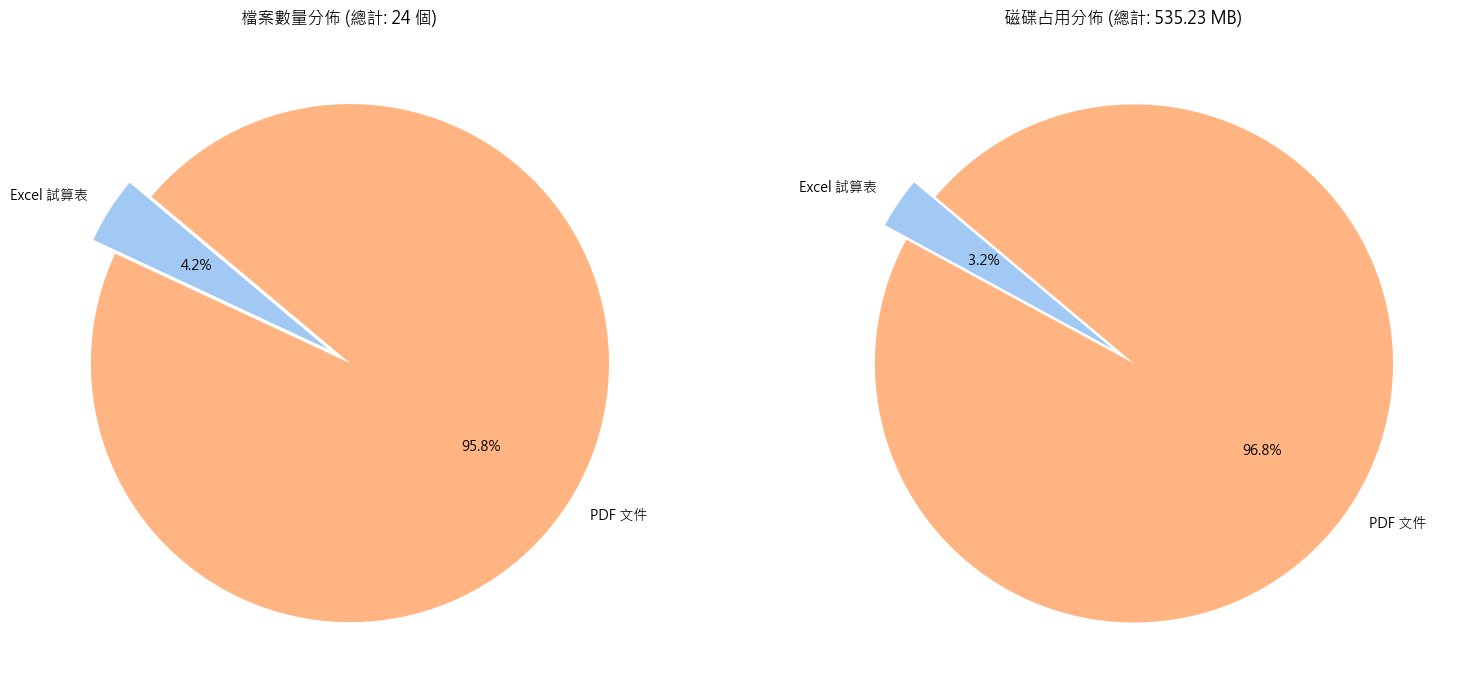

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 讀取清單檔案
list_save_path = 'file_list.csv'

if not os.path.exists(list_save_path):
    print(f"❌ 錯誤：找不到紀錄檔 '{list_save_path}'，請先執行 Cell 1 進行掃描。")
else:
    # 讀取資料
    df = pd.read_csv(list_save_path)
    
    # 2. 基礎數據計算
    total_files = len(df)
    total_size_kb = df['檔案大小(KB)'].sum()
    total_size_mb = total_size_kb / 1024
    
    # 3. 按「文件種類標籤」分組統計
    # 統計數量與大小
    type_stats = df.groupby('文件種類標籤').agg(
        檔案數量=('檔案名稱', 'count'),
        總大小_KB=('檔案大小(KB)', 'sum')
    ).reset_index()
    
    # 計算各類別大小 (MB) 方便閱讀
    type_stats['總大小_MB'] = type_stats['總大小_KB'] / 1024
    
    # 4. 輸出文字報告
    print(f"📊 --- 知識庫數據概覽 ---")
    print(f"總檔案數：{total_files} 個")
    print(f"總占用空間：{total_size_kb:.2f} KB ({total_size_mb:.2f} MB)")
    print("-" * 30)
    print(type_stats[['文件種類標籤', '檔案數量', '總大小_MB']].to_string(index=False))
    print("-" * 30)

    # 5. 可視化：繪製圓餅圖 (Pie Charts)
    # 設定中文字型（針對不同作業系統調整，這裡使用常見的字體設定）
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'SimHei'] 
    plt.rcParams['axes.unicode_minus'] = False
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    colors = sns.color_palette('pastel')[0:len(type_stats)]

    # 圓餅圖 1：檔案數量佔比
    ax1.pie(type_stats['檔案數量'], labels=type_stats['文件種類標籤'], autopct='%1.1f%%', 
            startangle=140, colors=colors, explode=[0.05]*len(type_stats))
    ax1.set_title(f'檔案數量分佈 (總計: {total_files} 個)')

    # 圓餅圖 2：檔案大小佔比
    ax2.pie(type_stats['總大小_KB'], labels=type_stats['文件種類標籤'], autopct='%1.1f%%', 
            startangle=140, colors=colors, explode=[0.05]*len(type_stats))
    ax2.set_title(f'磁碟占用分佈 (總計: {total_size_mb:.2f} MB)')

    plt.tight_layout()
    plt.show()

### 測試視覺抓取 [OCR/VLM]

#### 僅抓取第一頁

In [2]:
import pandas as pd
import requests
import base64
import os
import io
from pathlib import Path
from dotenv import load_dotenv
from pdf2image import convert_from_path

# 1. 載入環境變數與設定
load_dotenv()
POPPLER_PATH = os.getenv("POPPLER_PATH", "C:/Program Files/poppler-25.12.0/Library/bin")
OLLAMA_HOST = os.getenv("OLLAMA_HOST", "http://localhost:11434")
MODEL_NAME = os.getenv("VLM_MODEL_NAME", "llama3-vision")
OUTPUT_DIR = "./parsed_content/pdf_summaries"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def test_ollama_vlm(image_bytes, prompt="這是一份 PDF 文件的第一頁，請提取標題、摘要或主要目錄內容，並以 Markdown 格式輸出、忽略圖片上的印章樣式。"):
    """
    接收圖片位元組，呼叫遠端 Ollama VLM 進行測試與解析
    """
    url = f"{OLLAMA_HOST}/api/generate"
    try:
        # 將位元組轉為 base64
        b64_image = base64.b64encode(image_bytes).decode('utf-8')
        
        payload = {
            "model": MODEL_NAME,
            "prompt": prompt,
            "stream": False,
            "images": [b64_image]
        }
        response = requests.post(url, json=payload, timeout=120)
        response.raise_for_status()
        return response.json().get('response', '')
    except Exception as e:
        return f"❌ VLM 解析失敗: {str(e)}"

# --- 執行階段 ---

# 讀取清單並篩選 PDF
df = pd.read_csv('file_list.csv')
pdf_files = df[df['文件種類標籤'] == 'PDF 文件']

print(f"📄 準備處理 {len(pdf_files)} 份 PDF 的首頁視覺掃描...")
print("-" * 50)

results = []

for _, row in pdf_files.iterrows():
    pdf_path = row['檔案路徑']
    file_name = row['檔案名稱']
    
    print(f"🌀 正在轉換並讀取 PDF 首頁: {file_name}...", end="\r")
    
    try:
        # 2. 將 PDF 第一頁轉為圖片 (只取第一頁: first_page=1, last_page=1)
        images = convert_from_path(pdf_path, first_page=1, last_page=1, poppler_path=POPPLER_PATH)
        
        if images:
            # 將 PIL Image 轉為 Bytes 存入記憶體，不產生暫存檔
            img_byte_arr = io.BytesIO()
            images[0].save(img_byte_arr, format='JPEG')
            img_bytes = img_byte_arr.getvalue()
            
            # 3. 呼叫 VLM 解析
            analysis_result = test_ollama_vlm(img_bytes)
            
            # 儲存解析結果
            output_filename = f"{Path(file_name).stem}_summary.md"
            output_path = os.path.join(OUTPUT_DIR, output_filename)
            
            with open(output_path, "w", encoding="utf-8") as f:
                f.write(f"# PDF 視覺摘要: {file_name}\n\n")
                f.write(analysis_result)
            
            print(f"✅ 已完成首頁解析: {file_name} " + " " * 10)
            results.append({'檔案': file_name, '狀態': '成功', '摘要路徑': output_path})
        else:
            print(f"⚠️ 無法讀取 PDF 內容: {file_name}")
            
    except Exception as e:
        print(f"❌ 錯誤 ({file_name}): {e}")

print("-" * 50)
print(f"🚀 PDF 首頁掃描結束。")
pd.DataFrame(results).head()

📄 準備處理 23 份 PDF 的首頁視覺掃描...
--------------------------------------------------
✅ 已完成首頁解析: 00本因坊封面簽收單目錄.pdf           
✅ 已完成首頁解析: 01本因坊建築竣工圖.pdf           
✅ 已完成首頁解析: 02本因坊使用執照影本.pdf           
✅ 已完成首頁解析: 03本因坊公共設施及設備明細表.pdf           
✅ 已完成首頁解析: 04本因坊設施及設備廠商名冊.pdf           
✅ 已完成首頁解析: 05本因坊設施及設備保固證書及說明書.pdf           
✅ 已完成首頁解析: 06本因坊公共區域鑰匙點交清冊.pdf           
✅ 已完成首頁解析: 07本因坊工程驗收記錄表.pdf           
✅ 已完成首頁解析: 08本因坊施工相片.pdf           
✅ 已完成首頁解析: 01.本因坊目錄及移交簽收單(機電公設).pdf           
✅ 已完成首頁解析: 02.本因坊工程保固書(機電公設).pdf           
✅ 已完成首頁解析: 03.本因坊移交清單(機電公設).pdf           
✅ 已完成首頁解析: 04.本因坊廠商聯絡電話一覽表(機電公設).pdf           
✅ 已完成首頁解析: 05.本因坊器具設備操作說明(機電公設).pdf           
✅ 已完成首頁解析: 06.本因坊器具產品出廠證明(機電公設).pdf           
✅ 已完成首頁解析: 07.本因坊設備保固書(機電公設).pdf           
✅ 已完成首頁解析: 08.本因坊消防檢查合格資料(機電公設).pdf           
✅ 已完成首頁解析: 09.本因坊保全操作說明(機電公設).pdf           
✅ 已完成首頁解析: 10.本因坊照片(機電公設).pdf           
✅ 已完成首頁解析: 11.本因坊機電竣工圖說(資料光碟 1 張)機電公設.pdf           
✅ 已完成首頁解析: 本因坊 一.pdf           
✅ 已完成首頁解析: 本因坊 三.pdf     

,檔案,狀態,摘要路徑
0,00本因坊封面簽收單目錄.pdf,成功,./parsed_content/pdf_summaries\00本因坊封面簽收單目錄_su...
1,01本因坊建築竣工圖.pdf,成功,./parsed_content/pdf_summaries\01本因坊建築竣工圖_summ...
2,02本因坊使用執照影本.pdf,成功,./parsed_content/pdf_summaries\02本因坊使用執照影本_sum...
3,03本因坊公共設施及設備明細表.pdf,成功,./parsed_content/pdf_summaries\03本因坊公共設施及設備明細表...
4,04本因坊設施及設備廠商名冊.pdf,成功,./parsed_content/pdf_summaries\04本因坊設施及設備廠商名冊_...


### cell 4 完整PDF解析

In [ ]:
import pandas as pd
import requests
import base64
import os
import io
from pathlib import Path
from dotenv import load_dotenv
from pdf2image import convert_from_path
from tqdm.notebook import tqdm # Jupyter 專用進度條

# 1. 載入設定
load_dotenv()
OLLAMA_HOST = os.getenv("OLLAMA_HOST")
MODEL_NAME = os.getenv("VLM_MODEL_NAME")
POPPLER_PATH = os.getenv("POPPLER_PATH")
OUTPUT_BASE = "./parsed_content/full_docs"
os.makedirs(OUTPUT_BASE, exist_ok=True)

def call_vlm_for_page(image_bytes, page_num, total_pages):
    url = f"{OLLAMA_HOST}/api/generate"
    prompt = f"這是份文件的第 {page_num}/{total_pages} 頁。請精確提取圖中文字與表格，請在圖片位置放入'<圖片名稱>[圖片的描述]'，若有表格請用 Markdown 輸出。不要輸出多餘的開場白。"
    try:
        b64_image = base64.b64encode(image_bytes).decode('utf-8')
        payload = {"model": MODEL_NAME, "prompt": prompt, "stream": False, "images": [b64_image]}
        response = requests.post(url, json=payload, timeout=180)
        
        return response.json().get('response', '')
    except Exception as e:
        return f"\n> [頁面 {page_num} 解析錯誤: {e}]\n"

# 2. 讀取待處理清單
df = pd.read_csv('file_list.csv')
unprocessed_pdfs = df[(df['文件種類標籤'] == 'PDF 文件') & (df['處理狀態'] == 'unprocessed')]

if unprocessed_pdfs.empty:
    print("✨ 所有 PDF 文件均已處理完成。")
else:
    print(f"🚀 開始自動化 Pipeline，共有 {len(unprocessed_pdfs)} 個新 PDF 待處理...")
    
    # 總進度條
    pbar_total = tqdm(unprocessed_pdfs.iterrows(), total=len(unprocessed_pdfs), desc="總進度")

    for index, row in pbar_total:
        pdf_path = row['檔案路徑']
        file_name = row['檔案名稱']
        pbar_total.set_postfix(file=file_name[:20]) # 顯示當前處理檔案

        try:
            # 轉成圖片 (不限制頁數)
            images = convert_from_path(pdf_path, poppler_path=POPPLER_PATH)
            full_content = []
            
            # 單個檔案內部進度條
            pbar_file = tqdm(enumerate(images), total=len(images), desc=f"  📄 {file_name[:15]}...", leave=False)
            
            for i, img in pbar_file:
                img_byte_arr = io.BytesIO()
                img.save(img_byte_arr, format='JPEG', quality=80) # 壓縮品質平衡速度與精確度
                
                page_text = call_vlm_for_page(img_byte_arr.getvalue(), i+1, len(images))
                full_content.append(f"## 第 {i+1} 頁內容\n\n{page_text}\n")
            
            # 儲存完整 Markdown
            safe_name = "".join([c for c in Path(file_name).stem if c.isalnum() or c in (' ', '_')]).strip()
            save_path = os.path.join(OUTPUT_BASE, f"{safe_name}_full.md")
            
            with open(save_path, "w", encoding="utf-8") as f:
                f.write(f"# 完整文件解析: {file_name}\n\n")
                f.write("\n".join(full_content))
            
            # 5. 更新狀態為 processed
            df.at[index, '處理狀態'] = 'processed'
            # 每次處理完一個檔案就存一次 CSV，防止程式中斷前功盡棄
            df.to_csv('file_list.csv', index=False, encoding='utf-8-sig')
            
        except Exception as e:
            print(f"\n❌ 檔案 {file_name} 處理失敗: {e}")

    print("\n✅ 所有任務執行完畢！")

🚀 開始自動化 Pipeline，共有 16 個新 PDF 待處理...


總進度:   0%|          | 0/16 [00:00<?, ?it/s]

  📄 07本因坊工程驗收記錄表.pd...:   0%|          | 0/56 [00:00<?, ?it/s]

  📄 08本因坊施工相片.pdf...:   0%|          | 0/67 [00:00<?, ?it/s]

  📄 01.本因坊目錄及移交簽收單(...:   0%|          | 0/3 [00:00<?, ?it/s]

...

  📄 05.本因坊器具設備操作說明(...:   0%|          | 0/257 [00:00<?, ?it/s]

  📄 06.本因坊器具產品出廠證明(...:   0%|          | 0/27 [00:00<?, ?it/s]

  📄 07.本因坊設備保固書(機電公...:   0%|          | 0/27 [00:00<?, ?it/s]

  📄 08.本因坊消防檢查合格資料(...:   0%|          | 0/146 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [2]:
#單獨處理一個問題的測試，請勿刪除
import pandas as pd
import requests
import base64
import sys
import os
import io
from pathlib import Path
from dotenv import load_dotenv
from pdf2image import convert_from_path
from tqdm.notebook import tqdm # Jupyter 專用進度條

# 1. 載入設定
load_dotenv()
OLLAMA_HOST = os.getenv("OLLAMA_HOST")
MODEL_NAME = os.getenv("VLM_MODEL_NAME")
POPPLER_PATH = os.getenv("POPPLER_PATH")
OUTPUT_BASE = "./parsed_content/full_docs"
os.makedirs(OUTPUT_BASE, exist_ok=True)

# === 測試參數設定 ===
# 請在這裡填入你想要測試的單一 PDF 路徑
TEST_PDF_PATH = "C:/Users/Peiteng.Chuang/Desktop/璞真RAG/本因坊結案報告(提審)95.08.01.pdf" 
# ===================

def call_vlm_for_page(image_bytes, page_num, total_pages):
    url = f"{OLLAMA_HOST}/api/generate"
    prompt = f"這是份文件的第 {page_num}/{total_pages} 頁。請精確提取圖中文字與表格，請在圖片位置放入'<圖片名稱>[圖片的描述]'，若有表格請用 Markdown 輸出。不要輸出多餘的開場白。"
    try:
        b64_image = base64.b64encode(image_bytes).decode('utf-8')
        payload = {"model": MODEL_NAME, "prompt": prompt, "stream": False, "images": [b64_image]}
        response = requests.post(url, json=payload, timeout=180)
        return response.json().get('response', '')
    except Exception as e:
        return f"\n> [頁面 {page_num} 解析錯誤: {e}]\n"

# 2. 執行單一檔案測試
if not os.path.exists(TEST_PDF_PATH):
    print(f"❌ 找不到測試檔案: {TEST_PDF_PATH}")
else:
    file_name = os.path.basename(TEST_PDF_PATH)
    print(f"🚀 開始處理: {file_name}")

    try:
        # 第一步：PDF 轉圖片
        print("正在讀取 PDF 並轉換為圖片...")
        images = convert_from_path(TEST_PDF_PATH, poppler_path=POPPLER_PATH)
        total_pages = len(images)
        full_content = []
        
        # 第二步：啟動進度條 (使用 tqdm.notebook)
        # 確保 ncols 設定合適，避免換行
        pbar = tqdm(total=total_pages, desc="頁面解析進度", unit="page")
        
        for i, img in enumerate(images):
            # 更新進度條前綴文字
            pbar.set_description(f"正在解析第 {i+1}/{total_pages} 頁")
            
            img_byte_arr = io.BytesIO()
            img.save(img_byte_arr, format='JPEG', quality=80)
            
            page_text = call_vlm_for_page(img_byte_arr.getvalue(), i+1, total_pages)
            full_content.append(f"## 第 {i+1} 頁內容\n\n{page_text}\n")
            
            # 強制更新進度條
            pbar.update(1)
            sys.stdout.flush() 

        pbar.close() # 務必關閉進度條

        # 儲存結果
        safe_name = "".join([c for c in Path(file_name).stem if c.isalnum() or c in (' ', '_')]).strip()
        save_path = os.path.join(OUTPUT_BASE, f"{safe_name}_test_full.md")
        
        with open(save_path, "w", encoding="utf-8") as f:
            f.write(f"# 測試文件解析結果: {file_name}\n\n")
            f.write("\n".join(full_content))
        
        print(f"\n✅ 測試成功！檔案儲存至: {save_path}")

    except Exception as e:
        if 'pbar' in locals(): pbar.close()
        print(f"\n❌ 處理失敗: {e}")

🚀 開始處理: 本因坊結案報告(提審)95.08.01.pdf
正在讀取 PDF 並轉換為圖片...


頁面解析進度:   0%|          | 0/110 [00:00<?, ?page/s]


✅ 測試成功！檔案儲存至: ./parsed_content/full_docs\本因坊結案報告提審950801_test_full.md


### cell 5 轉換embedding